<a href="https://colab.research.google.com/github/elean23/2025-webinar-ml-with-python/blob/main/Module5Capsule2_abiertaUGR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![header_slide_abiertaugr_bigdata](https://i.imgur.com/qqwdHLo.png)
## Module 5.2 Standard classification methods.

**Author**:

*By* Prof. Alberto Fernández Hilario

Full Professor at the University of Granada, Andalusian Interuniversity Institute on Data Science and Computational Intelligence (DasCI)


## Brief Instructions

### Reminder: Introduction to NoteBook

The *Jupyter* (Python) notebook is an approach that combines blocks of text (like this one) along with blocks or cells of code. The great advantage of this type of cells is their interactivity, as they can be executed to check the results directly on them.

**Very important**: the order of the instructions (code blocks) is fundamental, so each cell of this notebook must be executed sequentially. In case of omitting any of them, the program may throw an error (an exit block will be displayed with a red message in English), so you should start from the beginning in case of doubt. To make this step easier, you can go to the "Run Environment" menu and click on "Run previous".

Go for it!

Click on the "play" button on the left side of each code cell. Lines starting with a hashtag (#) are comments and do not affect the execution of the programme.

You can also click on each cell and do "*ctrl+enter*" (*cmd+enter* on Mac).

When the first of the blocks is executed, the following message will appear:

"Warning: This notebook was not created by Google.

*The creator of this notebook is \@go.ugr.es. It may request access to your data stored in Google or read data and credentials from other sessions. Please review the source code before running this notebook. If you have any questions, please contact the creator of this workbook by sending an email to \<author>@go.ugr.es. "*

Don't worry, you will have to trust the contents of the Notebook and click on "*Run anyway*". All the code runs on an external compute server and will not affect your computer at all. No information or credentials will be requested, so you will be able to continue the course safely.

Each time you run a block, you will see the output just below it. The information is usually always the last instruction, along with any `print()` (print command) in the code.

## **INDEX**

In this *NoteBook*:
1. We introduce ‘white box’ classification paradigms.
2. We describe classification methods based on linear models.
3. We will study the nearest-neighbors classification algorithm.
4. We present the algorithm used to obtain classification decision trees.
5. We will discuss the advantages and disadvantages of all the above classifiers.
6. We demonstrate how to use all these classifiers with Python in *scikit-learn*.
7. We provide graphical examples of the decision boundaries of each model and consider their main differences in terms of their operation.

Contents:
1. Introduction.
2. Simple models: linear and logistic regression.
3. Classification based on the k-nearest neighbors model algorithm.
4. Decision trees.
5. Bibliography

## **1. INTRODUCTION**

In this first section we will provide a general introduction to classification paradigms, followed by specific examples of the paradigms described in this part of the course. We will then follow up by explaining how to load the melanoma cancer case study data we have been working with up until now.



### **1.1 Classification paradigms**

In Capsule 1 of this module we highlighted the fact that there are several types of discriminant functions which allow the enumeration of different classification paradigms or models: ‘white box’ and ‘black box’ models.

This section of the course will mainly focus on the former because they are the ‘first line of attack’ when one wants to solve a classification problem. The main reason for this is because these models are relatively easy and fast and are usually highly interpretable. This enables examination of the model components to identify the key variables used to divide the classes.

Thus, they allow users to understand whether the model makes sense with respect to the problem being studied, for example, from a biological point of view. Among the different classification algorithms highlighted in this group, we will introduce those based on linear and logistic regression, k-nearest neighbors, and decision trees.



### **1.2 Loading the problem data**

To test the behavior of the different sorting algorithms, we start by loading the case study data serving as the main thread throughout this course. The notation or code used is exactly the same as in previous activities from other modules.

In [1]:
import pandas as pd

#We load the expression matrix omics data from a shared file on Google Drive.
gene_exp_immune = pd.read_csv('https://drive.google.com/uc?id=1PYzEIdmnfjOnBpPDIFBE9hL1Lkj_OBCk',index_col=0)
#We load the clinical variable corresponding to the labels "immune" vs. "MITF-low".
clinical_info_immune = pd.read_csv('https://drive.google.com/uc?id=1hHQfcvrFa5Jds-9tW_X4sHjKpYKdii9s',index_col=0)

X, y = gene_exp_immune, clinical_info_immune

#We print the first 5 samples of the dataset to check that it has been loaded correctly.
X.head()

,COL2A1,RXRG,CCL19,SSX1,CST2,PRSS33,CDH2,SCUBE2,TMPRSS13,TRPM8,...,UBASH3A,GBP4,PRF1,PTK6,PCDHB2,GSDMA,DIO2,PLIN1,NCF1C,SLC7A11
0,-1.431141,-7.845756,0.665118,-1.409304,-2.537396,-1.676281,1.529957,-0.895042,-0.298778,5.091742,...,-0.659997,-1.469602,-0.570793,1.047635,-2.068966,-0.202828,-0.506767,1.285256,-0.901222,2.483020
1,-0.424374,-8.352423,0.386055,-2.846138,-0.685105,0.339787,-3.488043,-0.584982,5.679815,-1.117879,...,0.190202,-0.282190,0.375094,0.261662,3.356282,2.028145,-2.399010,-1.152801,0.662490,-2.914991
2,11.014251,0.415549,-1.633781,0.315442,-0.662332,-0.498761,0.535811,-0.467456,-2.818738,1.731049,...,-0.816305,-0.316202,-1.153745,-2.284201,-1.761597,-0.746975,-2.988195,-1.976877,-1.400889,-2.266779
3,-1.180446,-8.187415,-1.958023,5.061146,-2.603744,-0.666706,0.456460,-4.609624,-1.713164,-3.880876,...,0.214344,-0.327110,0.476764,1.153275,-0.337649,-1.006765,-2.686648,-1.329148,0.055994,-2.652313
4,0.816312,-1.189303,4.837235,4.972176,-2.963715,-2.665721,-0.268042,-1.740607,0.011610,-4.107467,...,3.352734,2.145368,3.358865,-2.324389,-1.741669,0.734312,-1.649316,6.284688,1.450729,1.131275


Additionally, we will use principal component analysis (PCA), which was introduced in Module 2, to transform the data set to contain only two dimensions (two input variables). This will allow the classification frontiers obtained by each classification technique to be represented in a remarkably straightforward way.

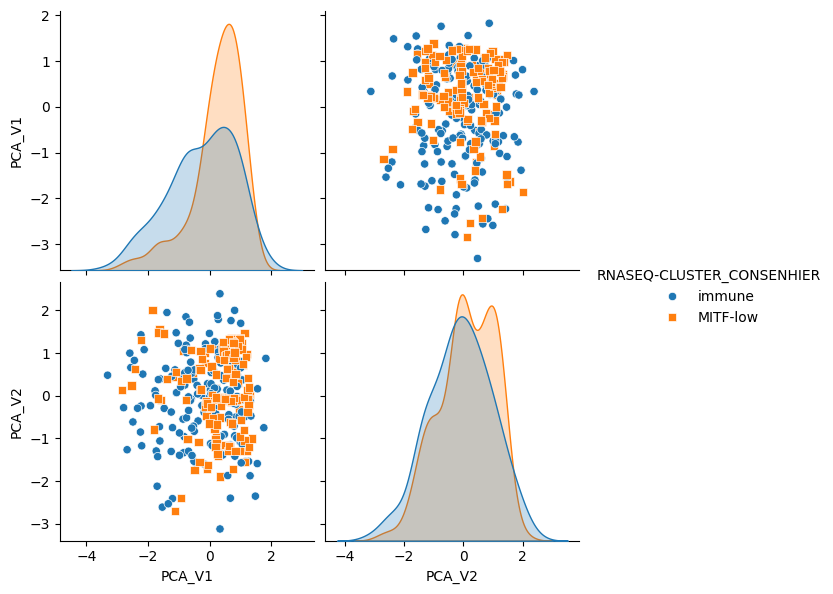

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Transform the initial dataset to be represented by only 2 variables
n_components = 2
pca = PCA(n_components=n_components)
X_2D = pca.fit_transform(X)

#The range of each variable is transformed to [0, 1].
st = StandardScaler()
X_2D = st.fit_transform(X_2D)

#We transform the resulting set to a data_frame structure (pandas) to facilitate graphical representation
df = pd.DataFrame(X_2D, columns = ['PCA_V1','PCA_V2'])
df = df.join(y)

#We show on a scatterplot the new 2D set, together with the density functions
sns.pairplot(df, hue='RNASEQ-CLUSTER_CONSENHIER', markers=["o", "s"], height=3);

For simplicity, a default hold-out validation will be used for the examples included in this NoteBook. For more details, see Module 3, Capsule 2 (Supervised learning).

Number of training instances: 252; and test: 84


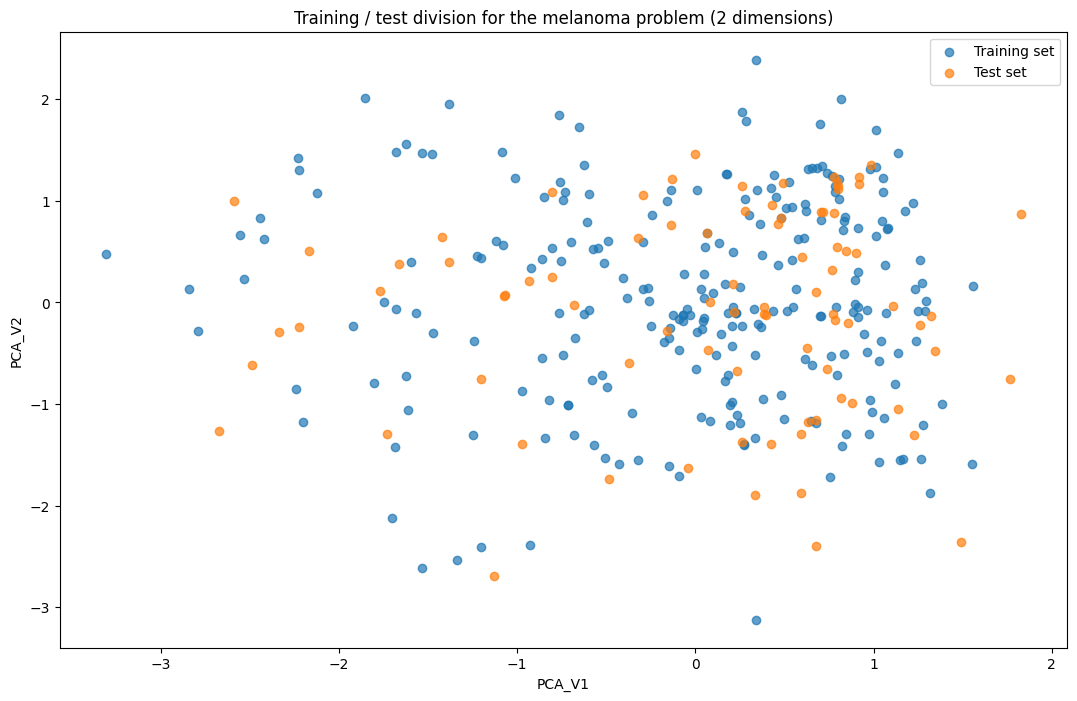

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

y_int = pd.get_dummies(y).iloc[:,0]
X_2D_train, X_2D_test, y_2D_train, y_2D_test = train_test_split(X_2D, y_int, random_state=42)

print(f"Number of training instances: {len(X_train)}; and test: {len(X_test)}")

#Next, we show the organisation of instances between training and test
#The distribution must be uniform across the input problem space
plt.figure(figsize=(13, 8))
plt.scatter(X_2D_train[:,0], X_2D_train[:,1],label='Training set', alpha=0.7)
plt.scatter(X_2D_test[:,0], X_2D_test[:,1],label='Test set', alpha=0.7)
plt.xlabel('PCA_V1')
plt.ylabel('PCA_V2')
plt.legend()
plt.title('Training / test division for the melanoma problem (2 dimensions)')
plt.show()

## **2. SIMPLE MODELS: LINEAR AND LOGISTIC REGRESSION**

In Module 4 (**Supervised Learning: regression techniques**) we studied functions that can approximate the actual output values for a set of data. This same idea can be applied directly to classification, considering output values belonging to an *‘n-ary’* set (binary for two classes) rather than in a real range. Here, first we will introduce the simplest possible model based on *simple linear regression*. In other words, a model based on a separating hyperplane (a ‘straight line’ dividing the instances). We will then extend this idea to current knowledge about logistic regression.




### **2.1 Linear regression model**

We will describe the primary features of this model and how it can be used in scikit-learn.



#### 2.1.1. Introduction to the linear model

As discussed at the beginning of this section, to adapt the *linear regression* learning format to a classification format, it is sufficient to learn or adjust the coefficients of a hyperplane by trying to approximate the output to the default values {0, 1}, following the same scheme of minimizing the residual sum of the squares. In this case, we must consider that we are working with a binary classification problem in which the first class is identified with the value “0” and the second with “1”.

Before continuing, it should be noted that hyperplanes are simple ‘cuts with a straight line’ for the classification of instances (i.e., they are a decision boundary). Thus, instances (or data points) that lie on either side of the hyperplane (‘straight line’) will be predicted as distinct classes. Logically, the dimension of the hyperplane depends on the number of input variables; if there are 2 input variables, the hyperplane will be a simple straight line. When the number of variables is 3, then the hyperplane becomes a two-dimensional plane. Handling more than 3 dimensions becomes complicated for human users.

The formula that divides the input space into two parts will be as follows.

\begin{equation}
\hat{y}(x,w) = w_0 + w_1 \cdot x_1 + \ldots + w_n \cdot x_n
\end{equation}

where $w = (w_1, \ldots, w_n)$ will be the coefficients associated with each input variable, and $w_0$ is the independent term. In the easy case of a one-dimensional problem, (one variable, $x$), one would look for the classical straight line $y = a \cdot x+b$.

![Example of linear regression for classification](https://i.imgur.com/OaGZIa8.png)

#### 2.1.2 Implementation in Scikit-Learn

To apply linear regression in classification tasks, the scikit-learn syntax is equivalent to the regression case. In this case example, the calculated coefficients are shown for each variable, (stored in the member variable `coef_`) and the independent term in the `intercept_`.

In [4]:
from sklearn import linear_model

lm = linear_model.LinearRegression()

#Here we do a little "trick" which is to transform the categorical output to {0,1} values.
#This step is necessary to apply the "regression" model which expects a real type output.
y_train_int = pd.get_dummies(y_train).iloc[:,0]

lm.fit(X_train, y_train_int)
print(lm.intercept_)
lm.coef_

0.3371977981689105


array([ 0.00062339, -0.01640629,  0.05765623, -0.00365438, -0.03219924,
        0.02831667,  0.02246995,  0.02406873,  0.04154468,  0.0113776 ,
        0.03335884,  0.02299525, -0.00375194,  0.04292671,  0.01228339,
       -0.01640771,  0.03062444, -0.00302422, -0.02929467,  0.00676286,
       -0.01947947, -0.02999738,  0.02491126, -0.0079843 , -0.00937148,
        0.00456585,  0.00615687, -0.01706812, -0.0042064 , -0.03262455,
       -0.03213231,  0.00450434, -0.05782194, -0.02456257,  0.0250594 ,
       -0.00637356,  0.04990764, -0.00675726, -0.04263797, -0.07777568,
        0.03133627,  0.01415696, -0.07683601, -0.08607171, -0.01192452,
        0.02302473,  0.06651956, -0.01050754,  0.04608665, -0.00776793])

As in the regression tasks (**Module 4**), the absolute value of each coefficient indicates the importance of that variable in approximating the output. Hence, we can interpret which data properties are most influential in distinguishing the classes. The following table shows a summary graph of the importance of the variables (subset of the genetic profiles of the top 5 variables) based on the value of the coefficients of the discriminant function.

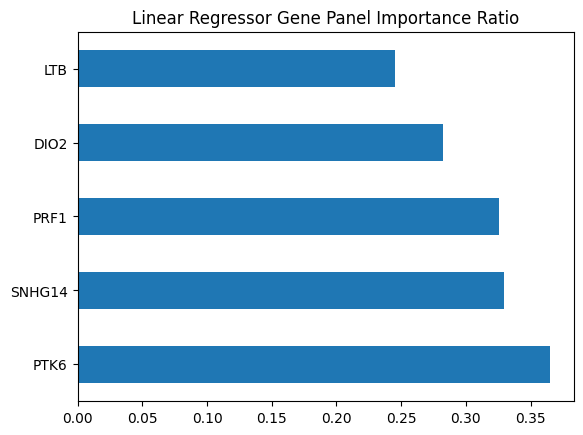

In [5]:
import numpy as np
from sklearn.preprocessing import normalize

importance = np.abs(lm.coef_) #transform to a one-dimensional list
#Normalize the values:
importance_norm = normalize(importance[:,np.newaxis], axis=0).ravel()

#The 5 most important are represented according to absolute value.
(pd.Series(importance_norm, index=X_train.columns).nlargest(5).plot(kind='barh'))
plt.title("Linear Regressor Gene Panel Importance Ratio")
plt.show()

Next, we will examine the quality of predictions generated according to the standard measure of accuracy (percentage correct). First, we note that the output obtained by the model is not a discrete value but rather, is a real value given that we are using a regression formula.

However, as indicated above, each class will be considered as an integer value. In this binary classification case study, the “MITF-Low” class will be class 0 and “immune” will be class 1, while a cut-off threshold of 0.5 will be used to determine the final class.


In [6]:
from sklearn.metrics import accuracy_score

#Transform the output back to a value {0,1}
y_test_int = pd.get_dummies(y_test).iloc[:,0]
y_pred = lm.predict(X_test)

print("Original predict values (top 10):")
print(y_pred[:10])
print()

print("Rounded prediction values (first 10):")

y_pred[y_pred >= 0.5] = 1
y_pred[y_pred < 0.5] = 0

print(y_pred[:10])
print()

acc_score = accuracy_score(y_test_int, y_pred)
print("Accuracy obtained:",acc_score)

Original predict values (top 10):
[ 1.29485689 -0.09064197  1.20110728  1.05823504  0.32454412  1.00993704
  0.65879706  0.6314562   0.2538342   0.45818503]

Rounded prediction values (first 10):
[1. 0. 1. 1. 0. 1. 1. 1. 0. 0.]

Accuracy obtained: 0.7142857142857143


### **2.2 Logistic regression model**



#### 2.2.1 Introduction to logistic regression

Despite the satisfactory results shown, linear regression is limited in many cases. Therefore, a technique known as *logistic regression* is preferred for data science tasks. Despite its name, it is a linear classification model rather than a regression model. In this case, the output function to be approximated would be the following:

\begin{equation}
\hat{y}(w,x) = \frac{1}{1+e^{ w_0 + w_1 \cdot x_1 + \ldots + w_n \cdot x_n}}
\end{equation}

The advantage of this approach over linear regression is that it creates a smoother separation between the values of the output variable (classes):

![Comparison Logistic vs. Linear regression](https://i.imgur.com/XTKnKp4.png)

#### 2.2.2 Implementation in scikit-learn and the main parameters

Below we will walk you through the steps required to build a logistic regression classifier in scikit-learn. Note that it follows exactly the same scheme as the one seen above for `LinearRegressor`; however, in this case, because it is a classifier, the output is in the set {0, 1}.

Several different parameters that can be configured for this classifier, although we recommend keeping the default values. In any case, the most important parameters are listed below:

- The `penalty` value specifies the rule used in the penalty function to adjust the coefficients; choose from {`l1`, `l2`, `elasticnet`, or `none`}, with the default being `l2`.
- `C` is a real value (`float`) used change the amount of forced overlearning, with higher values implying a better training fit, and with the default being 1.0.
- `class_weight` is used to alter the weighting given to under-represented class samples; choose between {`balanced` or `none`}, with the default being `none`.


Although not explicitly stated, many of the classifiers implemented in *scikit-learn* use the `class_weight` parameter by default so as to address *imbalanced classification* problems.

In the following code block, we will repeat the same steps performed for `linear regression` but implementing the `logistic regressor` classifier. Note that the same group of variables (genes) are highlighted as the main variables in both cases. Finally, the accuracy of this second model is higher, indicating the preference for this sort of solution.

Coef. independent: [2.6132476]
Coef. per variable: [[-0.03164268  0.16834903 -0.58375612 -0.04190438  0.40933645 -0.34784148
  -0.25764102 -0.2900071  -0.41804797 -0.31877227 -0.42102048 -0.21353913
   0.12120085 -0.59500971 -0.05204796  0.13913693 -0.54412221 -0.0474618
   0.30770307 -0.07267641  0.28545556  0.24966381 -0.39081724  0.19320498
   0.1238715   0.10128303 -0.14953995  0.37762084 -0.01990607  0.37740648
   0.34013146 -0.16327716  0.73300455  0.15970235 -0.29489846  0.07700014
  -0.24856328  0.26480726  0.5416622   0.77201506 -0.2079821  -0.34574431
   0.59905491  0.9712182   0.09633452 -0.21426204 -0.93500985  0.03436344
  -0.31479035  0.25492441]]



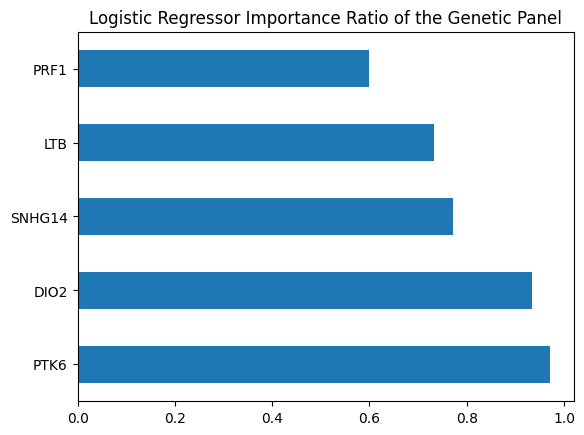


Original predicted values (top 10):
['MITF-low' 'immune' 'MITF-low' 'MITF-low' 'immune' 'MITF-low' 'MITF-low'
 'MITF-low' 'immune' 'immune']

Logistic Regression hit on test partition: 0.7380952380952381


In [7]:
import warnings
warnings.filterwarnings("ignore") #ignore this line

lrm = linear_model.LogisticRegression()

lrm.fit(X_train, y_train.to_numpy().ravel())
print("Coef. independent:",lrm.intercept_)
print("Coef. per variable:",lrm.coef_)
print()

importance = np.abs(lrm.coef_[0]) #transform to a one-dimensional list
importance_norm = normalize(importance[:,np.newaxis], axis=0).ravel()
#5 most important ones are represented by absolute value
(pd.Series(importance, index=X_train.columns).nlargest(5).plot(kind='barh'))
plt.title("Logistic Regressor Importance Ratio of the Genetic Panel")
plt.show()
print()

y_pred = lrm.predict(X_test)

print("Original predicted values (top 10):")
print(y_pred[:10])
print()

acc_score = accuracy_score(y_test, y_pred)
print("Logistic Regression hit on test partition:", acc_score)


In addition to the classical measure of accuracy, other measures can be used such as the *F1 metric* that compensates between the hits of each class, or the *AUC metric* based on the balance of true and false positives for each probability threshold value of the classifier.

Regardless, the graphical representation is immediate using a scikit-learn estimator or classifier. In the following code snippet we will review various ways of obtaining these aforementioned metrics.

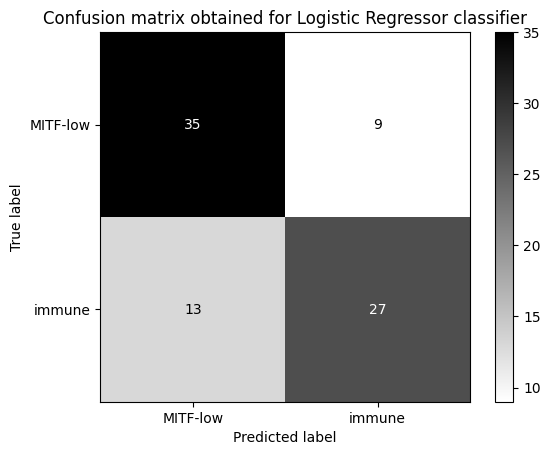

              precision    recall  f1-score   support

    MITF-low       0.73      0.80      0.76        44
      immune       0.75      0.68      0.71        40

    accuracy                           0.74        84
   macro avg       0.74      0.74      0.74        84
weighted avg       0.74      0.74      0.74        84

The F1 measure for classifier LogisticRegression is 0.7105
The AUC measure for classifier LogisticRegression is 0.7642


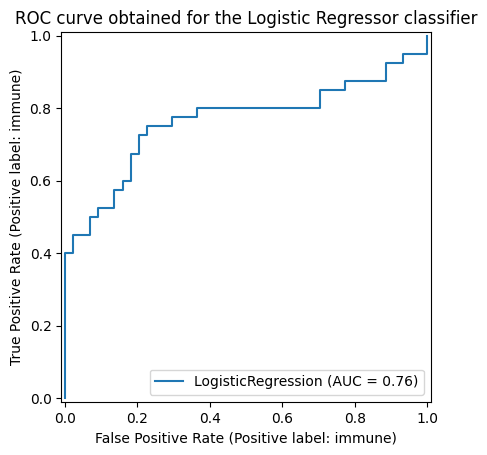

In [8]:
import matplotlib.pyplot as plt
from sklearn import metrics

metrics.ConfusionMatrixDisplay.from_estimator(lrm, X_test, y_test,cmap='binary')
plt.title("Confusion matrix obtained for Logistic Regressor classifier")
plt.show()

print(metrics.classification_report(y_test,y_pred))

f1 = metrics.f1_score(y_test,y_pred,pos_label="immune")
print("The F1 measure for classifier %s is %.4f"%(lrm.__class__.__name__,f1))

y_probs = lrm.predict_proba(X_test)
auc = metrics.roc_auc_score(y_test, y_probs[:,1])
print("The AUC measure for classifier %s is %.4f"%(lrm.__class__.__name__,auc))
metrics.RocCurveDisplay.from_estimator(lrm, X_test, y_test)
plt.title("ROC curve obtained for the Logistic Regressor classifier")
plt.show()

In the following section, the decision boundary obtained by each classifier used will be plotted. The most important thing about the representation of the decision or discriminant function is that it facilitates the understanding of how the different classification paradigms actually work.

It is highly likely that the `accuracy` attained will not exactly match the accuracy achieved with respect to the original data set, but this is understandable since we have transformed the problem.


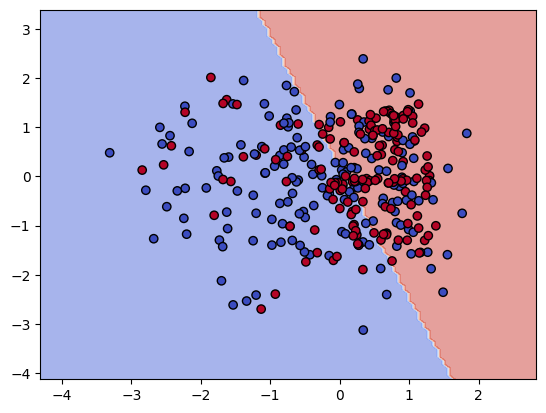

In [9]:
#A special library to 2D plot is imported
from sklearn.inspection import DecisionBoundaryDisplay

#We create and train the classifier with the 2D data
clf = linear_model.LogisticRegression()
clf.fit(X_2D_train, y_2D_train)
score = clf.score(X_2D_test,y_2D_test)

#Parameters that will be used to visualize the figure
disp = DecisionBoundaryDisplay.from_estimator(clf, X_2D,
                                              response_method="predict",
                                              alpha=0.5,
                                              cmap=plt.cm.coolwarm)

# We project the points from the dataset
disp.ax_.scatter(X_2D[:, 0], X_2D[:, 1],
                 c=y_int, edgecolor="k",
                 cmap=plt.cm.coolwarm)

plt.show()

### **2.3 Advantages and disadvantages of linear models**

Linear models have several advantages that are of great interest for practical use:

- They are very efficient and are therefore very appropriate for an initial approximation of the problem.
- An additional advantage is that they are highly interpretable, in the sense that they allow the weight or importance of the variables associated with the classification to be determined. Thus, we can check whether the input variables contain a biological meaning appropriate to the case study.
- Finally, they tend to work well even in problems with a high number of variables because both these models estimate the coefficients based on the independence of the input variables.


Therefore, if these input variables are correlated, we must remember that the estimation is highly sensitive to random errors in the output variable, producing a large variance. Hence, if the data for the problem are relatively complex, it is advisable to use more sophisticated non-linear techniques.



## **3. CLASSIFICATION WITH THE NEAREST NEIGHBOUR (KNN)**

In the previous capsule of this module, the k-nearest neighbors (KNN) model classification algorithm was briefly introduced. This was because of its simplicity and its widespread application in many data science and machine learning problems.

In this section, we will describe in more detail how the KNN algorithm works and its use by implementing Python in *scikit-learn*. Finally, we will discuss the advantages and disadvantages of this classification technique.



### **3.1 How the k-nearest neighbors algorithm works.**

The KNN algorithm falls under the heading of what is known as "*lazy learning*", in that it does not involve a training phase as such. Instead, ‘instance-based learning’ is performed for KNN models, making them a store for instances of the training data. The premise for classifying new instances is based on analyzing the class for similar instances. In simpler terms and to quote a popular saying, we could say that if it walks like a duck, and quacks like a duck, it probably is a duck!

![KNN example for a duck](https://i.imgur.com/YgHbcZ6.png)

The key, therefore, lies in what is meant by similarity between instances. To specify this, we must define what is known as a distance function, which will assign an output value between instances according to how similar they are. Because instances are represented in the form of numerical variables, the most common of these functions is the **Euclidean distance**, which is described by the following equation:

\begin{equation}
d_e(e_1, e_2) = \sqrt{\sum_{i=1}^{n}{(e_1^i - e_2^i)^2}}
\end{equation}

Note that in the two-dimensional case, it would coincide with the formula for finding the length of the hypotenuse in a right triangle, with the vertices of the legs being the points over which we want to find their distance.

To determine the output class of a new instance in the KNN algorithm, the distance value must be calculated for **all** available instances in the training set. The most frequent class among the KNN is then assigned to the new instance and **k** is a critical parameter in the use of this classification algorithm. Of note, k should always be an odd value to avoid possible ties. However, the optimal value of k is strongly data-dependent: in general, a larger value suppresses the effects of possible noise but makes the classification boundaries less clear.

![kNN Example](https://i.imgur.com/Z8sqWrw.gif)

### **3.2 Implementation of the k-nearest-neighbors model and its main usage parameters in scikit-learn**

As previously mentioned, the implementation of the KNN model in *scikit-learn* is found in the `KNeighborsClassifier` method and the most important parameters that can be set for it are as follows:

- `n_neighbors`: an integer value (`int`) to determine the neighborhood environment, with the default being `5`.
- `weights`: choose between {`uniform` or `distance`} depending on whether you want the output to be a simple vote or for the KNN output label to be more important, respectively, with the default being `uniform`.
- `metric`: choose from {`euclidean`, `manhattan`, `chebyshev`, `minkowski`, or `mahalanobis`} to determine the distance calculation, with the default being `minkowski`.

The following example shows how to implement KNN, when setting *k* (the `n_neighbors` parameter) to 3 and leaving the default settings for the other parameters. The other quality metrics can be obtained as previously described

In [10]:
from sklearn.neighbors import KNeighborsClassifier # load function from library

# Example of using kNN
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean') # instantiate the model
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

acc_score = accuracy_score(y_test, y_pred)
print("KNN accuracy on test partition:", acc_score)

KNN accuracy on test partition: 0.6785714285714286


The way to obtain other quality metrics is repeated:

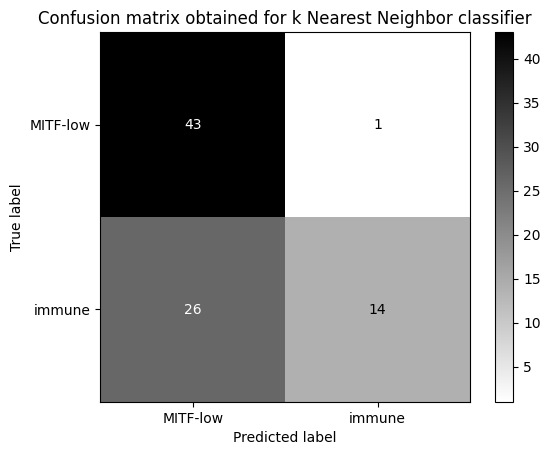

              precision    recall  f1-score   support

    MITF-low       0.62      0.98      0.76        44
      immune       0.93      0.35      0.51        40

    accuracy                           0.68        84
   macro avg       0.78      0.66      0.64        84
weighted avg       0.77      0.68      0.64        84

The F1 measure for classifier KNeighborsClassifier is 0.5091
The AUC measure for classifier KNeighborsClassifier is 0.7750


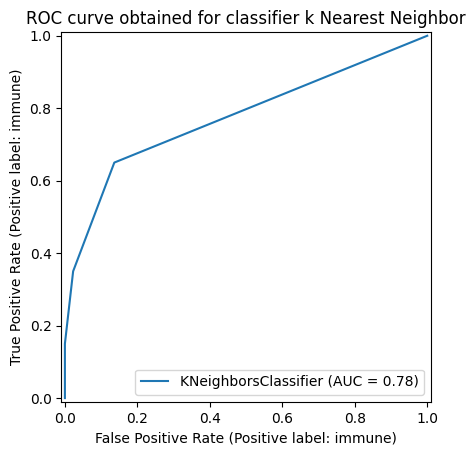

In [11]:
metrics.ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test,cmap='binary')
plt.title("Confusion matrix obtained for k Nearest Neighbor classifier")
plt.show()

print(metrics.classification_report(y_test,y_pred))

f1 = metrics.f1_score(y_test,y_pred,pos_label="immune")
print("The F1 measure for classifier %s is %.4f"%(knn.__class__.__name__,f1))

y_probs = knn.predict_proba(X_test)
auc = metrics.roc_auc_score(y_test, y_probs[:,1])
print("The AUC measure for classifier %s is %.4f"%(knn.__class__.__name__,auc))
metrics.RocCurveDisplay.from_estimator(knn, X_test, y_test)
plt.title("ROC curve obtained for classifier k Nearest Neighbor")
plt.show()

Again, we can check how the classification boundaries are defined in the case of this particular algorithm. Note the non-linear type of discriminant function (i.e., it is no longer a ‘straight line’) which is often also locally (very ‘closed’) in specific areas of the data space. Unlike previous linear models, the operation of **KNN** is based on the environment of the examples.

A considerable amount of time may be required to perform the computation required to obtain the graphical representation of the model in this example, given the efficiency characteristics of this algorithm

<Figure size 1200x900 with 0 Axes>

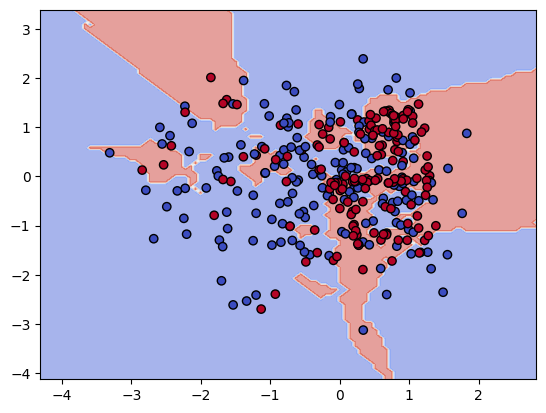

In [12]:
#We instantiate and train the classifier with the 2D data
clf = KNeighborsClassifier()
clf.fit(X_2D_train, y_2D_train)
score = clf.score(X_2D_test,y_2D_test)

fig = plt.figure(figsize=(12,9))
disp = DecisionBoundaryDisplay.from_estimator(clf, X_2D,
                                              response_method="predict",
                                              alpha=0.5,
                                              cmap=plt.cm.coolwarm)

# We project the points from the dataset
disp.ax_.scatter(X_2D[:, 0], X_2D[:, 1],
                 c=y_int, edgecolor="k",
                 cmap=plt.cm.coolwarm)

plt.show()

### **3.3 Advantages and disadvantages of the k-nearest-neighbors algorithm**

Finally, we will analyze the advantages and disadvantages of this classification algorithm that we should consider in the case study examined in this module

- **Advantages**:
  - The KNN model works well when using a moderate `k` value (`k > 1`) as the parameter, even with noisy instances whose value may be erroneous or anomalous. This implies that anomalous data instances should not affect the output of the classifier because they will be compensated by the remaining data that is correct.
  - The algorithm is also fairly efficient because it uses linear local functions to approximate the objective function. The frontier is non-linear and depends on the type of data sampling performed.
  - The model is valid for both classification and regression.
  - The KNN algorithm can easily be used with prototypes meaning that if, instead of using the whole training set, we only select the most important instances, the algorithm will run much faster without losing its predictive capability.
  - It is available in most software packages.


- **Disadvantages**:
  - The KNN model is very memory inefficient because the entire data set must be stored in the system.
  - The computational complexity is `O(d⋅n2)` while the distance complexity is `O(d)`. Therefore, the higher the number of instances, the slower the prediction.
  - The distance between neighbors in the KNN model may be dominated by irrelevant input variables. If the variables used are not correctly selected, they can strongly affect the prediction.
  - In the event of a high dimensionality, the distance converges to the same value, meaning that when there are a high number of variables, the distance or similarity tends to be identical for any instance upon which it is calculated.


## **4. DECISION TREES**

Decision trees (DTs) are a supervised learning technique used both for classification and regression. In this section, first we present the properties of decision tree-based techniques. Next, we describe the steps required to use the implementation available in the *scikit-learn* library. Finally, we list several general advantages and disadvantages associated with DTs .



### **4.1 Introduction to decision trees in classification**

DT models are based on simple `IF–THEN–ELSE+ format decision rules (or conditions) which are usually dichotomous (in groups of two). There is a hierarchical order in the application of the rules, which are chained until the final decision is made. Therefore, the model is usually structured in the form of a tree. Its elements are as follows:

- Each ‘leaf’ is a category (class) corresponding to the output.
- Each ‘node’ (internal part of the tree) specifies a simple test to be performed, in other words, a rule on a single tuple (a finite ordered list of \<variable, value\> elements).
- The ‘offspring’ of each node are the possible results of the node’s test.

![Example of a DT to classify animal species](https://i.imgur.com/xeeSMzw.png)

During the learning process, each node is expected to perform a disjointed division over the number of instances of each class. This division criterion is calculated using two possible measures: information gain (*entropy*) and impurity (*Gini index*). In short, the combination \<variable, value>\ that minimizes or maximizes the previous values (“entropy” or “gini”, respectively) is sought out. This implies that all the instances of a class are ‘grouped’ into the `IF` part of the rule, while the rest will go to the `ELSE` part.

According to the above, the most important input variables will appear at the top (`root`) of the tree. In the example shown in the image above this would be the color variable. This is because these variables are initially chosen as the most appropriate ones to separate between the classes of the problem. The training process is normally conducted recursively: starting by identifying the root and continuing until it reaches each of the leaves of the tree. We can determine that a leaf has been reached (and therefore no further splitting proceeds) based on two possible criteria:

- A node purity threshold is reached, as marked by the minimum or maximum value of the splitting measure (`entropy` or `gain`).
- The tree has reached a maximum depth limit set by the user. This depth is measured by the number of nodes from root to leaf.

Normally, the deeper the tree, the more complex the decision rules and the tighter the model. However, care must be taken as this type of tuning can lead to overlearning.


### **4.2 Implementation in scikit-learn and the main use parameters**

The `DecisionTreeClassifier` for creating decision tress is included in scikit-learn; its use is identical to the other classifiers implemented in this library and so we will focus on its main additional parameters:

- `criterion`: to determine the function that measures the quality of a split we must choose between {`gini` or `entropy`}, with the default being `gini`.
- `max_depth`: is an integer (`int`) that determines the maximum depth of the tree; if it is not specified, the nodes are expanded until all leaves are pure or until they contain less than `min_samples_split` instances.
- `min_samples_split`: is an integer (`int`) indicating the minimum number of instances needed to split an internal node, with the default being 2.


In [13]:
from sklearn import tree

dt = tree.DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

acc_score = accuracy_score(y_test, y_pred)
print("DT accuracy on the test partition:", acc_score)

DT accuracy on the test partition: 0.75


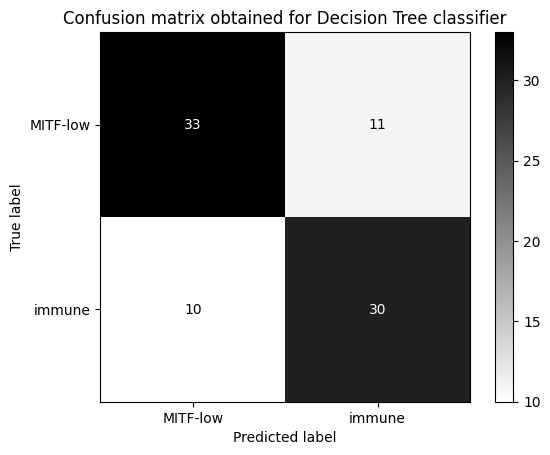

              precision    recall  f1-score   support

    MITF-low       0.77      0.75      0.76        44
      immune       0.73      0.75      0.74        40

    accuracy                           0.75        84
   macro avg       0.75      0.75      0.75        84
weighted avg       0.75      0.75      0.75        84

The F1 metric for classifier DecisionTreeClassifier is 0.7407
The AUC measure for classifier DecisionTreeClassifier is 0.7500


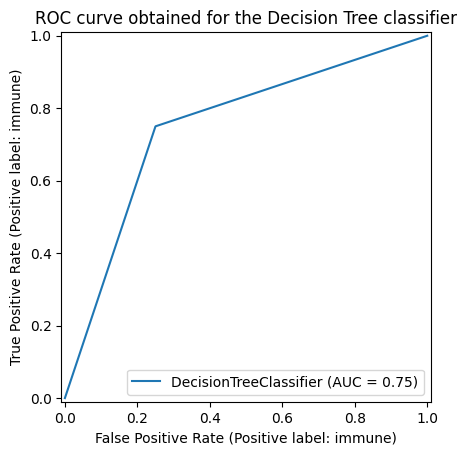

In [14]:
metrics.ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test,cmap='binary')
plt.title("Confusion matrix obtained for Decision Tree classifier")
plt.show()

print(metrics.classification_report(y_test,y_pred))

f1 = metrics.f1_score(y_test,y_pred,pos_label='immune')
print("The F1 metric for classifier %s is %.4f"%(dt.__class__.__name__,f1))

y_probs = dt.predict_proba(X_test)
auc = metrics.roc_auc_score(y_test, y_probs[:,1])
print("The AUC measure for classifier %s is %.4f"%(dt.__class__.__name__,auc))
metrics.RocCurveDisplay.from_estimator(dt, X_test, y_test)
plt.title("ROC curve obtained for the Decision Tree classifier")
plt.show()

One of the great advantages of decision trees is their good interpretability. Because simple rules are used in the tree format, it is very easy to determine its main components and the most useful variables representing the case. We can even directly explain each output from the classifier because it will take a single path from the root to the leaf node.

In the next block, we will visualize the tree generated, indicating the name of the input variables and classes. The colors (in this case, blue and orange) indicate most of output classes at each node, where the stronger the color, the better the separation of classes

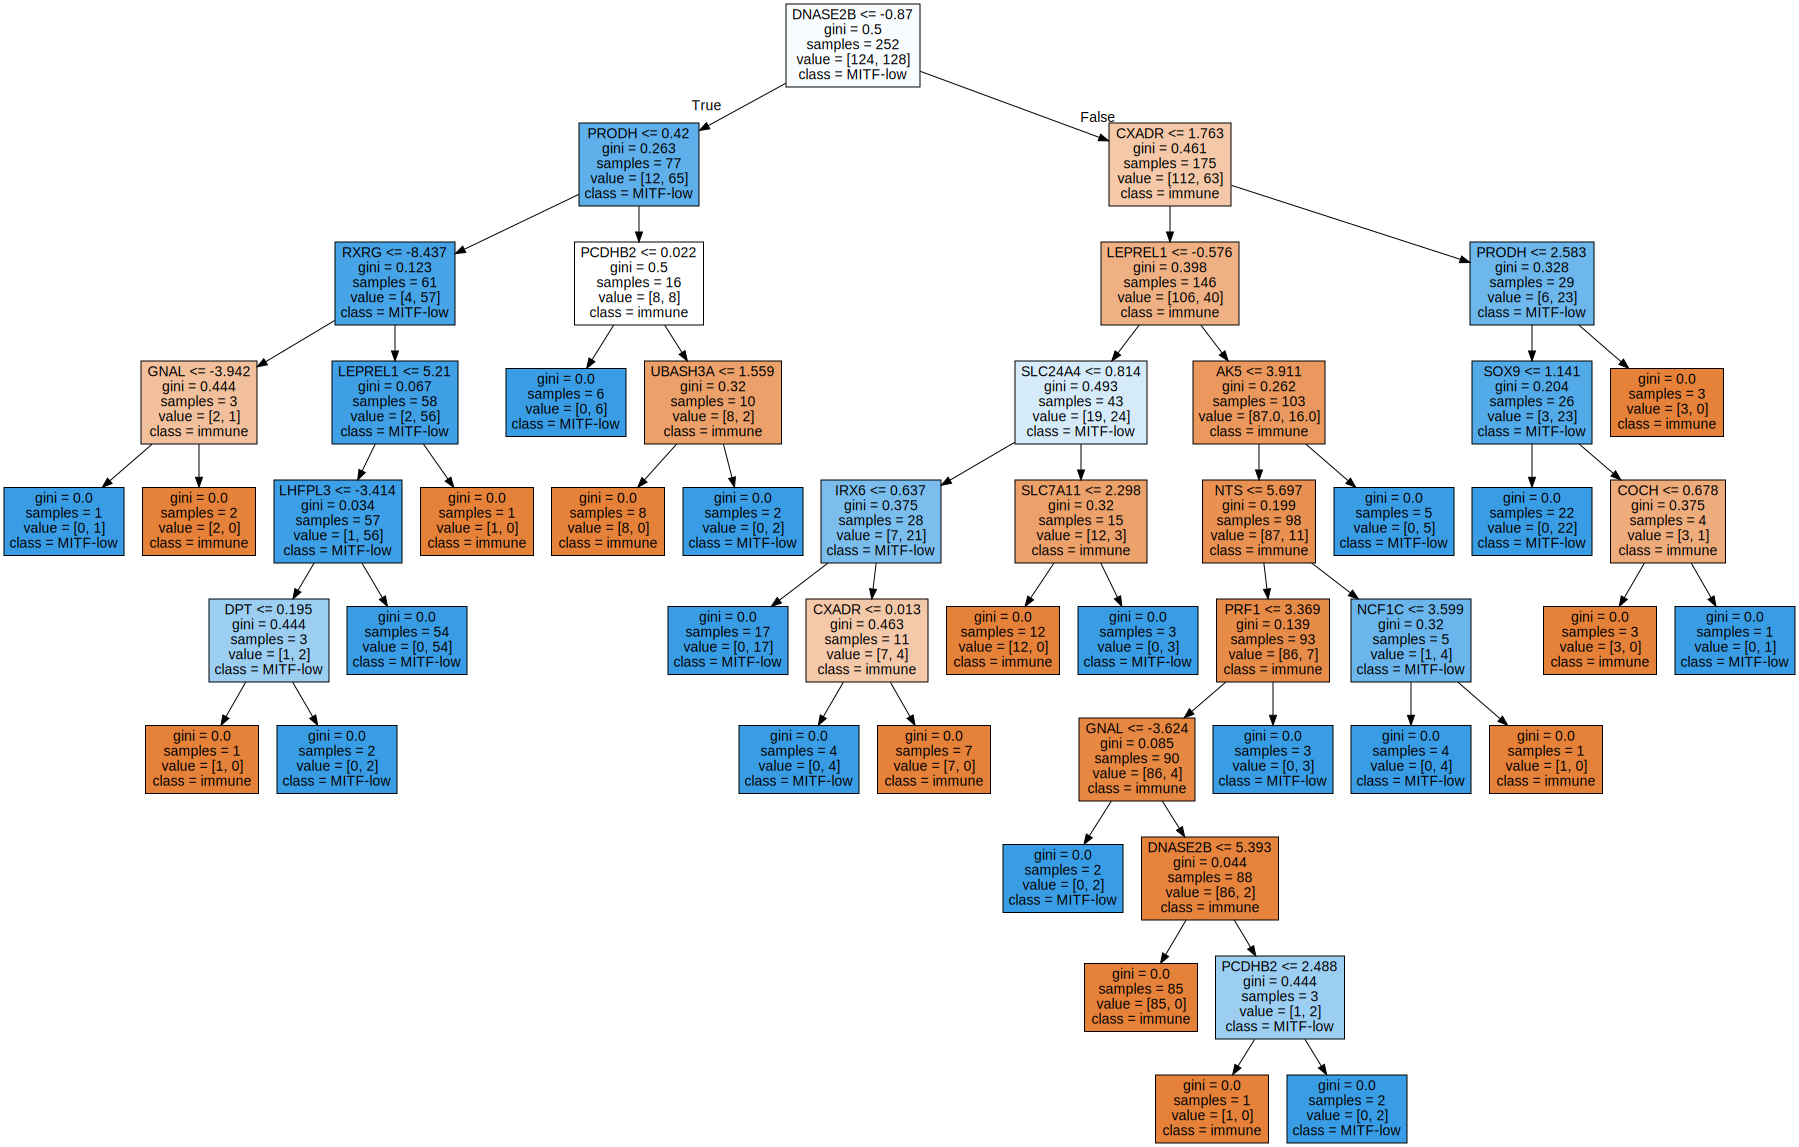

In [15]:
#Libraries needed for better visualisation
from graphviz import Source

#the tree is plotted:
tree_graph = tree.export_graphviz(dt, out_file=None,
                                  feature_names=X.columns,
                                  class_names=pd.unique(y[y.columns[0]]),
                                  filled = True)
graph = Source(tree_graph)
graph



As previously shown with a DT and the `LogisticRegressor` classifier, it is easy to check which variables are the most important in the model. These are usually the ones closest to the root node; the `DecisionTreeClassifier` class property allows us to access this information. As shown, the most important variable appears at the root of the tree.

This is not by chance but rather, because this one was first selected to divide the classes. Because the mode of learning of this model is different from that of the linear classification paradigm, the ranking of the most important variables also changes.

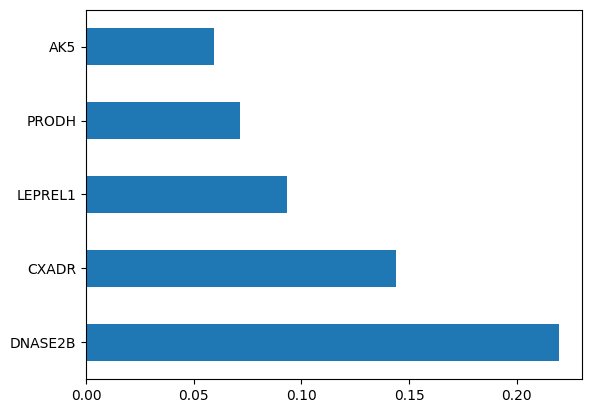

In [16]:
#First, the importance ranking values are captured.
importance = dt.feature_importances_
#The 5 most important ones are represented
(pd.Series(importance, index=X_train.columns).nlargest(5).plot(kind='barh'))
plt.show()

Finally, we proceed to represent the type of decision boundary obtained by the classification paradigm based on DTs. This time, we are shown a division by rectangular blocks according to how the examples are distributed in each node of the tree.

<Figure size 1200x900 with 0 Axes>

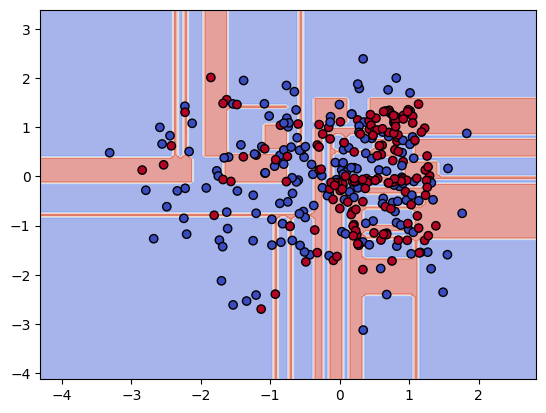

In [17]:
#We create and train the classifier with 2D data.
clf = tree.DecisionTreeClassifier()
clf.fit(X_2D_train, y_2D_train)
score = clf.score(X_2D_test,y_2D_test)

fig = plt.figure(figsize=(12,9))
disp = DecisionBoundaryDisplay.from_estimator(clf, X_2D,
                                              response_method="predict",
                                              alpha=0.5,
                                              cmap=plt.cm.coolwarm)

# We project the points from the dataset
disp.ax_.scatter(X_2D[:, 0], X_2D[:, 1],
                 c=y_int, edgecolor="k",
                 cmap=plt.cm.coolwarm)

plt.show()

### **4.3 Advantages and disadvantages of decision trees**

Decision trees are one of the most powerful tools used in machine learning. Among their main advantages, we would like to highlight the following:

- They are efficient and easy to use because they do not contain an excessive number of parameters, and these are simple to understand and configure, allowing their improved adaptation to the problem. In addition, its execution is very fast, so it allows continuous testing.
- The rules DTs generate are easy to interpret; one of their main virtues is that they are user-understandable systems because they use cognition rules like those that would be applied by an expert.
- DTs can be scaled better than other types of techniques and so increasing the number of instances or variables does not excessively affect the computational performance.
- These models can handle potentially noisy data by using an internal mechanism known as ‘*pruning*’ to heuristically reduce the depth of the tree and allow better generalization.

While we must certainly bear in mind the many positive aspects of DTs, some details that may affect their use should also be considered, namely:

- DTs cannot directly handle numerical input variables and so, to calculate entropy or Gini index functions, we must first turn the variables into discrete values. While this process is transparent to users, it should be taken into account.
- This type of model attempts to divide the variable domain into rectangular regions —a type of decision boundary that may not be suitable for some linear output distributions.
- DTs have difficulty dealing with missing data and so these values must be pre-imputed.
- If a very high depth factor is applied, it will be more difficult for DTs to correctly generalize over test instances, leading to problems with overlearning.
Correlations between variables may also be detected because each decision node is obtained independently without considering the rest.



## **BIBLIOGRAPHICAL REFERENCES**

-	Han, J., Kamber, M., Pei, J. (2011). Data Mining: Concepts and Techniques. San Francisco, CA, USA: Morgan Kaufmann Publishers. ISBN: 0123814790, 9780123814791
-	Witten, I. H., Frank, E., Hall, M. A., Pal, C. J. (2017). Data mining: practical machine learning tools and techniques. Amsterdam; London: Morgan Kaufmann. ISBN: 9780128042915 0128042915
- Scikit-Learn: Supervised Learning https://scikit-learn.org/stable/supervised_learning.html (visitado el 25 de Junio de 2020).
- Open Machine Learning Course: Topic 3. Classification, Decision Trees and k Nearest Neighbors https://mlcourse.ai/articles/topic3-dt-knn/ (visitado el 25 de Junio de 2020).


### **Additional references**

-	Alpaydin, E. (2016). Machine Learning: The New AI. MIT Press. ISBN: 9780262529518
- Towards Data Science: The Complete Guide to Classification in Python https://towardsdatascience.com/the-complete-guide-to-classification-in-python-b0e34c92e455 (visitado el 25 de Junio de 2020).
- Towards Data Science: Python For Data Science — A Guide To Classification Machine Learning https://towardsdatascience.com/python-for-data-science-a-guide-to-classification-machine-learning-9ff51d237842 (visitado el 25 de Junio de 2020).



<div class="alert alert-block alert-success">
MOOC Machine Learning and Big Data for Bioinformatics (2nd edition)   

http://abierta.ugr.es

![CC](https://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc-nd.png)
</div>    